# <h1 align="center"> Machine Learnign Template </h1> </center>

<p style="margin-bottom:1cm;"></p>

## ML-day 4 exercise gave the base of it


__Topic covered__

- Logistic Regression
- KNN
- Naive Bayes
- SVM
- Decision Tree
- RandomForestClassifier
- AdaBoost
- Gradient Boosting
- XGBoost
- Feature Importance

## 1. Load Dependencies

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## 2. Loading Dataset


In [3]:
df = pd.read_csv("telecom_users.csv")
print(df.shape)
df.head()

(5986, 22)


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1869,7010-BRBUU,Male,0,Yes,Yes,72,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,4528,9688-YGXVR,Female,0,No,No,44,Yes,No,Fiber optic,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.2,No
2,6344,9286-DOJGF,Female,1,Yes,No,38,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,6739,6994-KERXL,Male,0,No,No,4,Yes,No,DSL,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.5,No
4,432,2181-UAESM,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.5,No


Churn = yes - they leave the company - e.g. bad
Churn = no - they stay - e.g. good

## 3. Data Preparation and check (shape, info for the column types, checking for missing values)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5986 non-null   int64  
 1   customerID        5986 non-null   object 
 2   gender            5986 non-null   object 
 3   SeniorCitizen     5986 non-null   int64  
 4   Partner           5986 non-null   object 
 5   Dependents        5986 non-null   object 
 6   tenure            5986 non-null   int64  
 7   PhoneService      5986 non-null   object 
 8   MultipleLines     5986 non-null   object 
 9   InternetService   5986 non-null   object 
 10  OnlineSecurity    5986 non-null   object 
 11  OnlineBackup      5986 non-null   object 
 12  DeviceProtection  5986 non-null   object 
 13  TechSupport       5986 non-null   object 
 14  StreamingTV       5986 non-null   object 
 15  StreamingMovies   5986 non-null   object 
 16  Contract          5986 non-null   object 


In [5]:
df.isna().sum() #same as isnull, but this is the newer and preferred format. 

Unnamed: 0          0
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### But it is always a decision how we are dealing with missing data.

### Filtering for duplicates
We also need to figure out with the duplicates. We can keep the last one of the copies, or only keep the duplicates and drop the rest. 
It is also not necessary to pick a column to check, so then it compares all the rows.

After filtering we might need to reset the rows with .reset_index(drop=True)

In [6]:
df = df.drop_duplicates(keep="last")
len(df)

5986

## 4. Splitting the data
With limited amount of data (<1000) it is usually better to do the split with smaller split size (10%).

In [7]:
X = df.drop(columns=['ATTACK SUCCESS'])
y = df['ATTACK SUCCESS']


Xy_train, X_valid, Xy_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)#Stratify makes sure that the split of the data will have the same proportion of the "y" variable as the original dataset. Basically the next line of code for the proportion checking becomes unnecessary. 
Xy_train.shape, X_valid.shape

KeyError: "['ATTACK SUCCESS'] not found in axis"

### My model has to be more accurate than the proportion of the data, otherwise we are basically better to go with random data, because that has a higher chance of hitting our target

In [ ]:
print(y_train.value_counts(normalize=True), y_test.value_counts(normalize=True))

## 5. Aggregate of the categorical data, so there are less instances of rare events

In [14]:
cols = df.columns.tolist()	           #The easiest way to get all the columns as a list

In [ ]:
#separation fo cat vs num columns.

cat_cols = df.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()
num_cols = df.select_dtypes(include=['int', 'float']).columns.tolist()

In [ ]:
# counts = {}
# for c in cat_cols:
#     counts = df[c].value_counts()
#     rare = counts[counts < 8].index              #I chose 8 because it is 1% of the whole dataset.
#     df[c] = df[c].replace(rare, "Other")
# for c in cat_cols:
#     print(df[c].value_counts(),"\n" )             #"\n" is a new line character, to make it easier to read.

## 6. Correlation matrixes to see how the data behaves

### Person, Spearman, Kendall correlations for numerical values.

In [23]:
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Have to fix this part, my cat_cols or num_cols are a list of columns but these need df-s. 

AttributeError: 'list' object has no attribute 'corr'

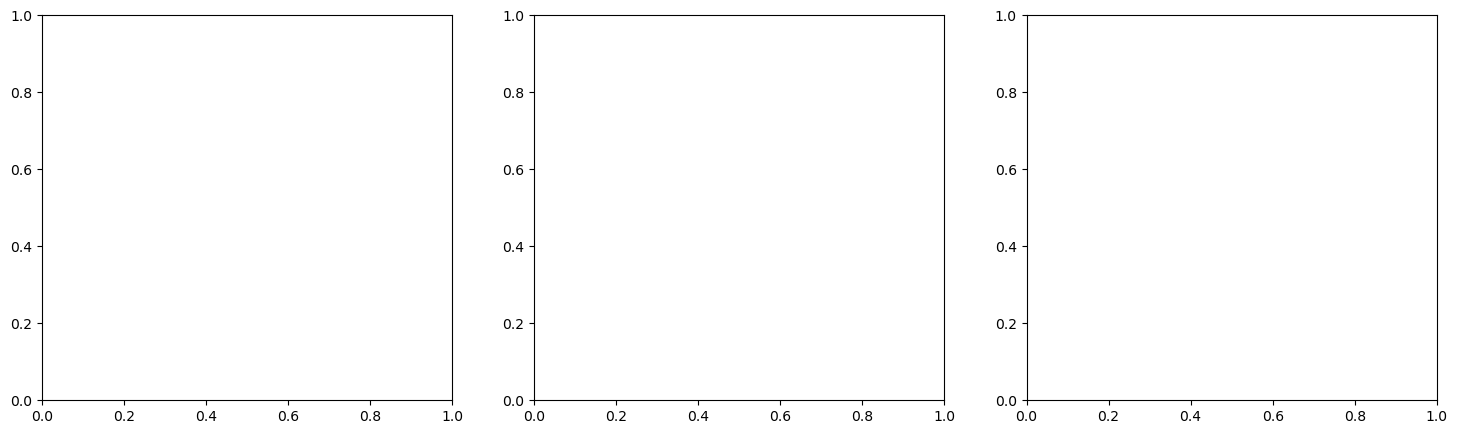

In [ ]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, method in zip(axes, ["pearson", "spearman", "kendall"]):
    sns.heatmap(num_cols.corr(method=method), ax=ax, cmap="coolwarm", vmin=-1, vmax=1,
                annot=True, fmt=".2f", square=True, cbar=False)
    ax.set_title(method.capitalize())
plt.tight_layout()
plt.show()
 


### Cramér's V (categorical vs categorical)

In [ ]:
# %% 3. Cramér's V (categorical vs categorical)
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))
 
cols = cat_cols.columns
cv = pd.DataFrame([[cramers_v(cat_cols[a], cat_cols[b]) for b in cols] for a in cols],
                  index=cols, columns=cols)
 
sns.heatmap(cv, cmap="Blues", vmin=0, vmax=1, annot=True, fmt=".2f", square=True)
plt.title("Cramér's V")
plt.show()
 

In [ ]:
# %% 4. VIF (numeric only, NaN rows dropped)
X = add_constant(num_cols.dropna())
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
                index=X.columns).drop("const").sort_values()
 
vif.plot.barh(color=["tab:red" if v > 10 else "tab:blue" for v in vif])
plt.axvline(5, ls="--", c="grey")
plt.axvline(10, ls="--", c="red")
plt.title("VIF (>5 check, >10 problem)")
plt.show()

Correlation tests are deeply dependent on what kind of correlation we are looking at .

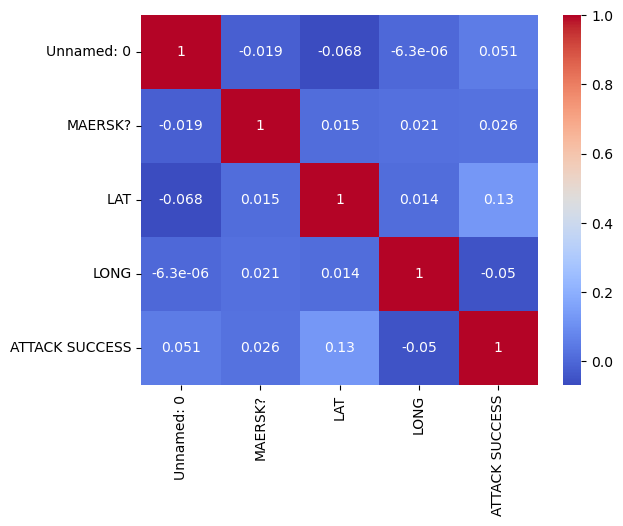

In [39]:
import seaborn as sns #potentially drops categorical values immediately.
plt.figure()
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm');

# 7. Feature engineering and filtration 
DATE (UTC) was kept in case it is interesting

In [42]:
df_clean = df.drop(columns=["TIMEZONE","DATETIME (UTC)","DATE (LT)", "Unnamed: 0", "DATETIME (LOCAL)", "INCIDENT TYPE"])
df_clean.head()

,DATE (UTC),REGION,COUNTRY,VESSEL TYPE,MAERSK?,VESSEL ACTIVITY LOCATION,LAT,LONG,TIME OF DAY,ATTACK SUCCESS
0,2016-01-30,WEST AFRICA,NIGERIA,CONTAINER SHIP,0,OFF SHORE,3.000000,6.250000,EVENING,0
1,2016-01-29,WEST AFRICA,NIGERIA,PRODUCT TANKER,0,OFF SHORE,2.500000,5.750000,EVENING,1
2,2016-01-28,SOUTH ASIA,INDIA,PRODUCT TANKER,0,ANCHORAGE,22.816667,70.116667,NIGHT,0
3,2016-01-27,HORN OF AFRICA/ GULF OF ADEN,SOMALIA,NaN,0,OFF SHORE,13.998747,54.112792,UNKNOWN,0
4,2016-01-25,SOUTH AMERICA,VENEZUELA,GENERAL CARGO VESSEL,0,ANCHORAGE,10.267500,-63.432500,EVENING,1


## Separate categorical and numeric columns

We will need to treat these features separately just like before

In [173]:
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['int', 'float']).columns.tolist()


# 8. Training 



## Define Categorical and Numerical Transformer Pipeline

Tranformation of the categorical features:

- Constant imputer (SimpleImputer) to fill missing values
- One-hot encoder to get dummy variables

Tranformation of the categorical features:

- Standard Scaler to scale the numeric features
- K-nearest neighbor imputer to fill missing values

Processor: tranform all the features in sequence

- Numeric Transfomer defined earlier
- Categorical Transfomer defined earlier

In [ ]:
categorical_transformer = Pipeline(steps=[
                                          ("cat_imputer", SimpleImputer(strategy='constant',
                                                                        fill_value='Not Available').set_output(transform="pandas")),
                                          ("onehot", OneHotEncoder(sparse_output=False,
                                                                   handle_unknown="ignore").set_output(transform="pandas"))
                                          ])

numeric_transformer = Pipeline(steps=[
                                      ("scaler", StandardScaler().set_output(transform="pandas")),
                                      ("knn_imputer", KNNImputer(n_neighbors=5).set_output(transform="pandas")) #This is in here to fill in NaN-s because some model would crush on missing vales. 
                                      ])

preprocessor = ColumnTransformer(transformers=[
                                               ("num", numeric_transformer,
                                                       numeric_features),
                                               ("cat", categorical_transformer,
                                                       categorical_features)
                                               ]).set_output(transform="pandas")

## Logistic Regression Modeling Pipeline

Chains the following steps:

- Preprocessing pipeline steps defined earlier (categorical to numerical encoding, scaling, filling NaNs)
- Logistic Regression model 

In [ ]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline(steps=[
                              ("pre_process", preprocessor),
                              ("model", LogisticRegression(random_state=42, solver='liblinear'))
                              ])

## Train and Evaluate Logistic Regression ML Pipeline



In [ ]:
pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)

class_labels = pipeline_lr.named_steps['model'].classes_ #I do not know what is the purpose of these class lables. 

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)




              precision    recall  f1-score   support

           0       0.64      0.45      0.53        31
           1       0.71      0.84      0.77        50

    accuracy                           0.69        81
   macro avg       0.67      0.65      0.65        81
weighted avg       0.68      0.69      0.68        81



,0,1
0,14,17
1,8,42


### This is another way of creating a confusion matrix

In [ ]:
cf = confusion_matrix(y_test, y_pred)
sns.heatmap(cf, annot=True, fmt="d")

In [ ]:
scores = {}
scores['log_reg'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

## Here is a good place to check quickly if the aggregation helped or not.

## Train and Evaluate K Nearest Neighbors (KNN) ML Pipeline


### This first part is for finding the best neighbour in the current split.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

best_neighbour = {}
for n in range(1, 51, 2):
    pipeline_knn = Pipeline([("scaler", StandardScaler().set_output(transform="pandas")),
                            ("model", KNeighborsClassifier(n_neighbors=n))])
    pipeline_knn.fit(X_train, y_train)
    y_pred = pipeline_knn.predict(X_test)

    best_neighbour[n] = cross_val_score(pipeline_knn, X_train, y_train, cv=3, scoring="f1_macro").mean()
    
df_neighbour = pd.DataFrame(list(best_neighbour.items()), columns=["n_neighbours", "f1_score"])


In [187]:
fig = px.line(x=df_neighbour["n_neighbours"], y=df_neighbour["f1_score"], title="F1 score in the light of number of neighbours")
fig.show()

## Using the best neighbour number in the actual model pipeline

In [ ]:
pipeline_knn = Pipeline([("pre_process", preprocessor),
                            ("model", KNeighborsClassifier(n_neighbors=9))])

pipeline_knn.fit(X_train, y_train)
y_pred = pipeline_knn.predict(X_test)

class_labels = pipeline_knn.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

           0       0.55      0.52      0.53        31
           1       0.71      0.74      0.73        50

    accuracy                           0.65        81
   macro avg       0.63      0.63      0.63        81
weighted avg       0.65      0.65      0.65        81



,0,1
0,16,15
1,13,37


In [190]:
scores['knn'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.678, 'knn': 0.652}

## Train and Evaluate SVM ML Pipeline


In [ ]:
from sklearn.svm import LinearSVC
pipeline_svc = Pipeline([("pre_process", preprocessor),
                         ("model", LinearSVC(random_state=42, max_iter=10000))])


pipeline_svc.fit(X_train, y_train)
y_pred = pipeline_svc.predict(X_test)

class_labels = pipeline_svc.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

           0       0.54      0.48      0.51        31
           1       0.70      0.74      0.72        50

    accuracy                           0.64        81
   macro avg       0.62      0.61      0.61        81
weighted avg       0.64      0.64      0.64        81



,0,1
0,15,16
1,13,37


In [ ]:
scores['svm'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.678, 'knn': 0.652, 'nb': 0.696, 'svm': 0.638}

## Train and Evaluate Naive Bayes ML Pipeline
This model does not need scaling.
MultinomialNB / ComplementNB would crash after standardization, given the negative values.

Which distribution to use:
- BernoulliNB assumes binary (0/1) features. By default it binarises every feature at binarize=0.0, so with continuous, all-positive data nearly everything becomes 1 and the model loses most of the information.
- GaussianNB is the one for continuous numeric features. 
- MultinomialNB is for counts, like word frequencies.

In [ ]:
categorical_transformer = Pipeline(steps=[
                                          ("cat_imputer", SimpleImputer(strategy='constant',
                                                                        fill_value='Not Available').set_output(transform="pandas")),
                                          ("onehot", OneHotEncoder(sparse_output=False,
                                                                   handle_unknown="ignore").set_output(transform="pandas"))
                                          ])

numeric_transformer = Pipeline(steps=[
                                      ("knn_imputer", KNNImputer(n_neighbors=5).set_output(transform="pandas")) # no standard scaling for numeric data
                                      ]) #see there is no scaler here

preprocessor_new = ColumnTransformer(transformers=[
                                               ("num", numeric_transformer,
                                                       numeric_features),
                                               ("cat", categorical_transformer,
                                                       categorical_features)
                                               ]).set_output(transform="pandas")

In [ ]:
from sklearn.naive_bayes import BernoulliNB

pipeline_nb = Pipeline([("pre_process", preprocessor_new),
                         ("model", BernoulliNB())
                         ])

pipeline_nb.fit(X_train, y_train)
y_pred = pipeline_nb.predict(X_test)

class_labels = pipeline_nb.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

           0       0.64      0.52      0.57        31
           1       0.73      0.82      0.77        50

    accuracy                           0.70        81
   macro avg       0.69      0.67      0.67        81
weighted avg       0.70      0.70      0.70        81



,0,1
0,16,15
1,9,41


In [ ]:
scores['nb'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.678, 'knn': 0.652, 'nb': 0.696}

## Tree-based models don't require data to be scaled - hence the new processer is used down the line.

Tree based models are non-linear and are not distance based models. Hence we will create a new transformation pipeline without scaling

## Train and Evaluate Decision Tree ML Pipeline


In [ ]:
from sklearn.tree import DecisionTreeClassifier
pipeline_dtree = Pipeline([("pre_process", preprocessor_new),
                         ("model", DecisionTreeClassifier(random_state=42))])


pipeline_dtree.fit(X_train, y_train)
y_pred = pipeline_dtree.predict(X_test)

class_labels = pipeline_dtree.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

           0       0.44      0.48      0.46        31
           1       0.66      0.62      0.64        50

    accuracy                           0.57        81
   macro avg       0.55      0.55      0.55        81
weighted avg       0.58      0.57      0.57        81



,0,1
0,15,16
1,19,31


In [202]:
scores['dtree'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.678, 'knn': 0.652, 'nb': 0.696, 'svm': 0.638, 'dtree': 0.571}

## Train and Evaluate Random Forest ML Pipeline


In [ ]:
from sklearn.ensemble import RandomForestClassifier
pipeline_rf = Pipeline([("pre_process", preprocessor_new),
                         ("model", RandomForestClassifier(random_state=42))])

pipeline_rf.fit(X_train, y_train)
y_pred = pipeline_rf.predict(X_test)

class_labels = pipeline_rf.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

           0       0.54      0.42      0.47        31
           1       0.68      0.78      0.73        50

    accuracy                           0.64        81
   macro avg       0.61      0.60      0.60        81
weighted avg       0.63      0.64      0.63        81



,0,1
0,13,18
1,11,39


In [207]:
scores['rf'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.678,
 'knn': 0.652,
 'nb': 0.696,
 'svm': 0.638,
 'dtree': 0.571,
 'rf': 0.631}

## Train and Evaluate AdaBoost ML Pipeline


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

pipeline_ada_boost = Pipeline([("pre_process", preprocessor_new),
                         ("model", AdaBoostClassifier(random_state=42))])


pipeline_ada_boost.fit(X_train, y_train)
y_pred = pipeline_ada_boost.predict(X_test)

class_labels = pipeline_ada_boost.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

           0       1.00      0.13      0.23        31
           1       0.65      1.00      0.79        50

    accuracy                           0.67        81
   macro avg       0.82      0.56      0.51        81
weighted avg       0.78      0.67      0.57        81



,0,1
0,4,27
1,0,50


In [211]:
scores['ada_boost'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.678,
 'knn': 0.652,
 'nb': 0.696,
 'svm': 0.638,
 'dtree': 0.571,
 'rf': 0.631,
 'ada_boost': 0.574}

## Train and Evaluate Gradient Boosting ML Pipeline


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

pipeline_gbm = Pipeline([("pre_process", preprocessor_new),
                         ("model", GradientBoostingClassifier(random_state=42))])


pipeline_gbm.fit(X_train, y_train)
y_pred = pipeline_gbm.predict(X_test)

class_labels = pipeline_gbm.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

           0       0.53      0.32      0.40        31
           1       0.66      0.82      0.73        50

    accuracy                           0.63        81
   macro avg       0.59      0.57      0.57        81
weighted avg       0.61      0.63      0.61        81



,0,1
0,10,21
1,9,41


In [216]:
scores['gbm'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.678,
 'knn': 0.652,
 'nb': 0.696,
 'svm': 0.638,
 'dtree': 0.571,
 'rf': 0.631,
 'ada_boost': 0.574,
 'gbm': 0.605}

## Train and Evaluate Extreme Gradient Boosting (XGBoost) ML Pipeline


In [ ]:
from xgboost import XGBClassifier
pipeline_xgb = Pipeline([("pre_process", preprocessor_new),
                         ("model", XGBClassifier(random_state=42))])

In [220]:
# Doesn't work with string y labels
# ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['<=50K' '>50K']
# Need to label encode
pipeline_xgb.fit(X_train, y_train)

,steps,"[('pre_process', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### This next bit is only needed if y is not numerical or not categorical.

In [221]:
# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# # transform y labels into 0 and 1 as latest xgboost version doesn't support string labels
# y_train_le = le.fit_transform(y_train)
# y_test_le = le.transform(y_test)

In [222]:
pipeline_xgb.fit(X_train, y_train)
y_pred = pipeline_xgb.predict(X_test)

In [223]:
# y_train_le[:10]

In [224]:
# pipeline_xgb.fit(X_train, y_train_le)
# y_pred_le = pipeline_xgb.predict(X_test)
# y_pred_le[:10]

In [225]:
# # reverse transform predicted 0s and 1s into string labels
# y_pred = le.inverse_transform(y_pred_le)
# y_pred[:10]

In [226]:
#class_labels = le.classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

           0       0.49      0.55      0.52        31
           1       0.70      0.64      0.67        50

    accuracy                           0.60        81
   macro avg       0.59      0.59      0.59        81
weighted avg       0.62      0.60      0.61        81



,0,1
0,17,14
1,18,32


In [227]:
scores['xgb'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.678,
 'knn': 0.652,
 'nb': 0.696,
 'svm': 0.638,
 'dtree': 0.571,
 'rf': 0.631,
 'ada_boost': 0.574,
 'gbm': 0.605,
 'xgb': 0.609}

## Compare model performances

In [228]:
result = pd.DataFrame({
    "Model" : scores.keys(),
    'F1-Score': scores.values()
})

result

,Model,F1-Score
0,log_reg,0.678
1,knn,0.652
2,nb,0.696
3,svm,0.638
4,dtree,0.571
5,rf,0.631
6,ada_boost,0.574
7,gbm,0.605
8,xgb,0.609


In [229]:
list(scores.keys())

['log_reg', 'knn', 'nb', 'svm', 'dtree', 'rf', 'ada_boost', 'gbm', 'xgb']

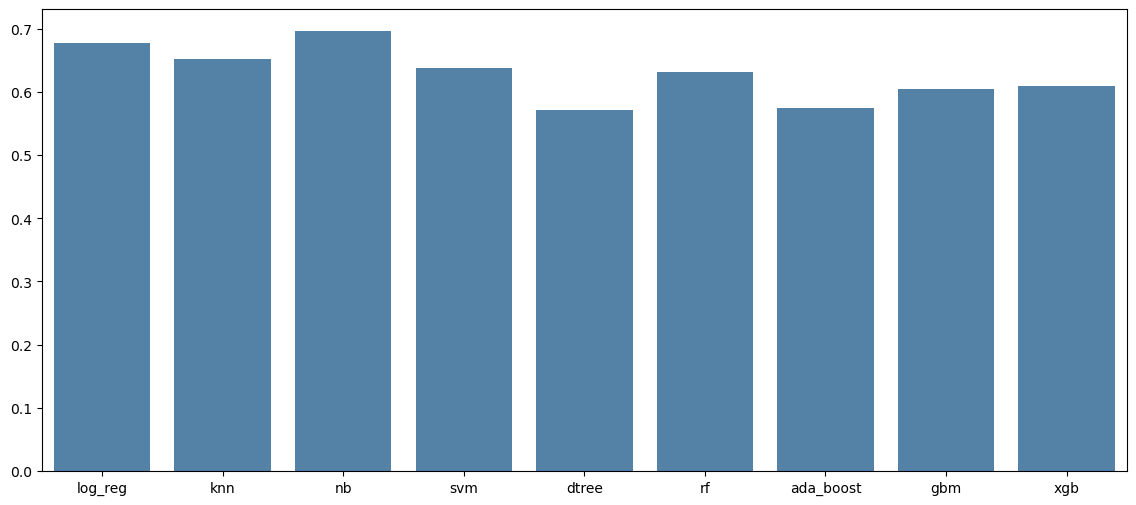

In [230]:
plt.figure(figsize=(14, 6))
sns.barplot(x=list(scores.keys()),
            y=list(scores.values()), color="Steelblue");

## Feature Importance

Trees based models like RandomForest, XGBoost, etc.  provide us feature importance based on the training.

In [231]:
pipeline_xgb

,steps,"[('pre_process', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [232]:
xgb_model = pipeline_xgb['model']
xgb_model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [233]:
pipeline_xgb['pre_process']

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,5
,weights,'uniform'


In [234]:
feature_names = pipeline_xgb['pre_process'].get_feature_names_out()
feature_names

array(['num__MAERSK?', 'num__LAT', 'num__LONG',
       'cat__DATE (UTC)_2015-01-04', 'cat__DATE (UTC)_2015-01-07',
       'cat__DATE (UTC)_2015-01-08', 'cat__DATE (UTC)_2015-01-09',
       'cat__DATE (UTC)_2015-01-11', 'cat__DATE (UTC)_2015-01-12',
       'cat__DATE (UTC)_2015-01-13', 'cat__DATE (UTC)_2015-01-14',
       'cat__DATE (UTC)_2015-01-15', 'cat__DATE (UTC)_2015-01-17',
       'cat__DATE (UTC)_2015-01-18', 'cat__DATE (UTC)_2015-01-20',
       'cat__DATE (UTC)_2015-01-21', 'cat__DATE (UTC)_2015-01-22',
       'cat__DATE (UTC)_2015-01-23', 'cat__DATE (UTC)_2015-01-24',
       'cat__DATE (UTC)_2015-01-25', 'cat__DATE (UTC)_2015-01-28',
       'cat__DATE (UTC)_2015-01-30', 'cat__DATE (UTC)_2015-01-31',
       'cat__DATE (UTC)_2015-02-01', 'cat__DATE (UTC)_2015-02-02',
       'cat__DATE (UTC)_2015-02-03', 'cat__DATE (UTC)_2015-02-04',
       'cat__DATE (UTC)_2015-02-05', 'cat__DATE (UTC)_2015-02-06',
       'cat__DATE (UTC)_2015-02-09', 'cat__DATE (UTC)_2015-02-10',
       'cat__D

In [235]:
xgb_model.feature_importances_

array([0.01200422, 0.01796548, 0.01837906, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.01012024, 0.00818134, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.00988181, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [236]:
xgb_importances = pd.DataFrame(
    {"feature": feature_names, "importance": np.round(xgb_model.feature_importances_, 3)}
)
xgb_importances = xgb_importances.sort_values("importance", ascending=False).set_index(
    "feature"
)
xgb_importances.head(20)

,importance
feature,
cat__REGION_HORN OF AFRICA/ GULF OF ADEN,0.103
cat__COUNTRY_NIGERIA,0.061
cat__REGION_WEST AFRICA,0.057
cat__VESSEL TYPE_MERCHANT VESSEL,0.054
cat__COUNTRY_TOGO,0.042
cat__COUNTRY_INDONESIA,0.030
cat__TIME OF DAY_UNKNOWN,0.029
cat__COUNTRY_INDIA,0.028
cat__VESSEL TYPE_PASSENGER VESSEL,0.027


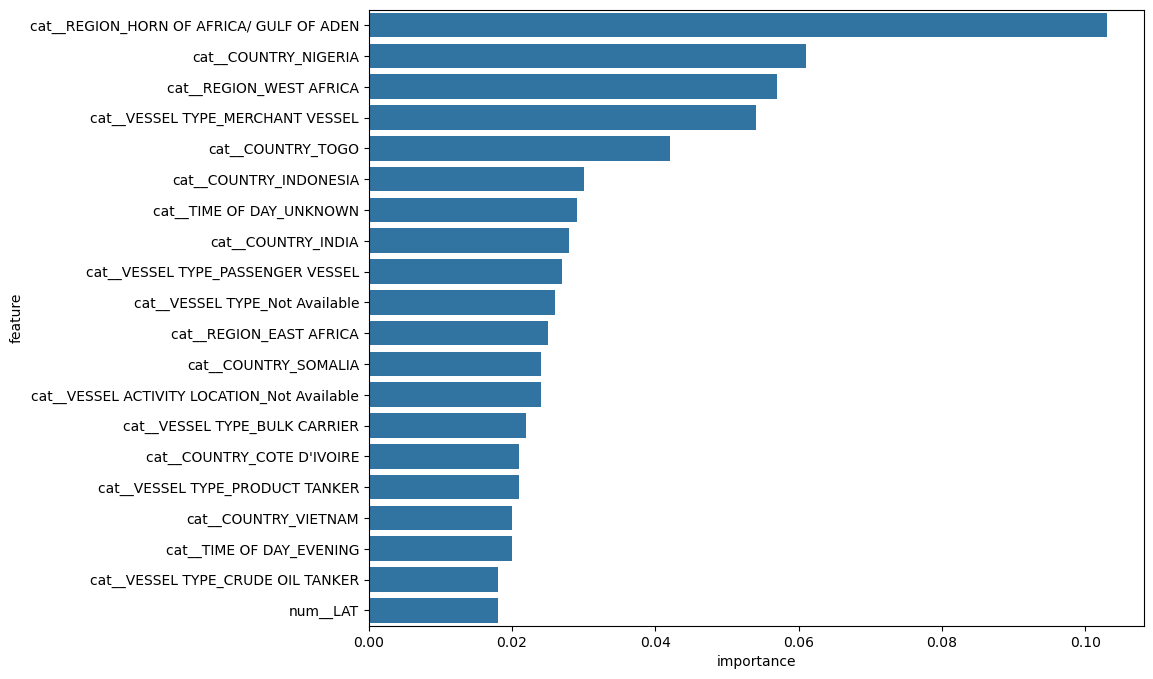

In [237]:
plt.figure(figsize=(10, 8))
sns.barplot(y=xgb_importances.head(20).index,
            x=xgb_importances.head(20).importance);

## Cross-Validation Evaluation and Model Comparison (Optional)

Standard process followed in the industry to compare multiple ML models

In [238]:
from sklearn.model_selection import cross_val_score

#### Cross-Validating based on Average F1 score

In [241]:
cvs = 10
scores_cv = {}
scores_cv['log_reg'] = cross_val_score(pipeline_lr, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['knn'] = cross_val_score(pipeline_knn, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['nb'] = cross_val_score(pipeline_nb, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['svm'] = cross_val_score(pipeline_svc, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['dtree'] = cross_val_score(pipeline_dtree, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['rf'] = cross_val_score(pipeline_rf, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['ada_boost'] = cross_val_score(pipeline_ada_boost, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['gbm'] = cross_val_score(pipeline_gbm, X_train, y_train, cv=cvs, scoring='f1_weighted')
# here labels need to be used as 0 and 1 which are label encoded
scores_cv['xgb'] = cross_val_score(pipeline_xgb, X_train, y_train, cv=cvs, scoring='f1_weighted')

In [242]:
result = pd.DataFrame({
    "Model" : scores_cv.keys(),
    'F1-Score': [round(np.mean(scores), 3) for scores in scores_cv.values()]
})

result.sort_values("F1-Score", ascending=False)

,Model,F1-Score
8,xgb,0.652
1,knn,0.647
4,dtree,0.640
5,rf,0.637
0,log_reg,0.612
3,svm,0.599
2,nb,0.596
7,gbm,0.571
6,ada_boost,0.530


XGB gives the best CV score for weighted average F1 of around 63.5 %